# TopLoc HNSW — best speedup under an allowed quality loss (Dragon + Snowflake)

**Goal.** Find the best speedup TopLoc offers over plain HNSW when we allow a
bounded quality loss, for both embedding models, and compare against Table 1 of
Muntean et al., SIGIR '25.

**Definitions.**
* **Baseline anchor** = baseline quality at the stabilization point: the first
  `efSearch` beyond which no larger ef improves the metric by more than
  `STAB_EPS` (robust version of the plateau).
* **Quality loss** of a TopLoc config = anchor − TopLoc quality (negative = gain).
* **Tolerance (TOL)** = the loss we accept: {0.0, 0.005, 0.01}.

**Symmetric comparison.** The quality floor (anchor − TOL) applies to both
systems; each side is represented by its **cheapest config clearing the floor**,
so the baseline is never forced to overspend on quality the comparison does not
require.

**Process** per model, thread mode, metric, tolerance:
1. anchor = stabilized baseline quality; 2. floor = anchor − TOL;
3. baseline ref = cheapest baseline ≥ floor; 4. qualifying TopLoc runs ≥ floor;
5. speedup = baseline ref time / TopLoc time (amortized, q0 included);
6. best speedup highlighted. Run per metric and for all three metrics combined.

In [ ]:
DATASETS = {
    "Dragon":    "/home/toploc1/Datasets/toploc1/HNSW_paper1/dragon_hnsw32_metrics.json",
    "Snowflake": "/home/toploc1/Datasets/toploc1/HNSW_paper1/snowflake_hnsw32_metrics.json",
}
METRICS   = ("NDCG@10", "MRR@10", "NDCG@3")
TOLS      = (0.0, 0.005, 0.01)   # allowed quality loss vs the baseline anchor
STAB_EPS  = 0.0005               # improvement below this = "stabilized"
EPS       = 1e-12                # float-comparison guard

# for the paper-style summary table at the end:
REPORT_MODE = "multi"            # thread mode to report (paper uses one socket)
REPORT_TOLS = {"Dragon": 0.01,   # tolerance whose winner becomes the TopLoc row,
               "Snowflake": 0.0}  # chosen per model

In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TIME = "avg_query_time_ms"
FRAMES = {}
for model, path in DATASETS.items():
    with open(path) as f:
        raw = json.load(f)
    df = pd.DataFrame.from_dict(raw, orient="index")
    df.index.name = "config"
    df = df.reset_index()
    df["method"] = np.where(df["config"].str.startswith("toploc"),
                            "TopLoc", "baseline")
    for c in ["efSearch", "up", TIME, *METRICS]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    FRAMES[model] = (df[df.method == "baseline"].copy(),
                     df[df.method == "TopLoc"].copy())
    modes = sorted(set(df.thread_mode))
    print(f"{model}: {len(FRAMES[model][0])} baseline / "
          f"{len(FRAMES[model][1])} TopLoc configs, modes {modes}")

MODES = ["single", "multi"]
MODELS = list(DATASETS)

Dragon: 26 baseline / 130 TopLoc configs, modes ['multi', 'single']
Snowflake: 26 baseline / 130 TopLoc configs, modes ['multi', 'single']


## Analysis functions

In [3]:
def frames(model, mode):
    b, t = FRAMES[model]
    return b[b.thread_mode == mode], t[t.thread_mode == mode]


def stabilized_quality(b, metric):
    """Quality at the first efSearch beyond which no larger ef ever
    improves the metric by more than STAB_EPS."""
    bb = b.sort_values("efSearch")
    vals = bb[metric].to_numpy()
    tail_max = np.maximum.accumulate(vals[::-1])[::-1]
    for i, v in enumerate(vals):
        if tail_max[i] - v <= STAB_EPS + EPS:
            return float(v), int(bb["efSearch"].iloc[i])
    return float(vals[-1]), int(bb["efSearch"].iloc[-1])


def cheapest_clearing(rows, floors):
    """Cheapest config whose quality is >= floor on every listed metric."""
    ok = rows
    for m, f in floors.items():
        ok = ok[ok[m] >= f - EPS]
    return None if ok.empty else ok.loc[ok[TIME].idxmin()]


def quality_loss_table(model, mode, metric, tol):
    """Per-metric analysis for one model, mode, tolerance."""
    b, t = frames(model, mode)
    plateau, anchor_ef = stabilized_quality(b, metric)            # step 1
    floor = plateau - tol                                         # step 2
    base_ref = cheapest_clearing(b, {metric: floor})              # step 3
    qual = t[t[metric] >= floor - EPS].copy()                     # step 4

    tbl = pd.DataFrame({
        "up": qual["up"].astype(int),
        "ef": qual["efSearch"].astype(int),
        f"TopLoc {metric}": qual[metric],
        f"baseline {metric}": base_ref[metric],
        "quality loss": plateau - qual[metric],   # vs anchor; negative = gain
        "TopLoc ms/query": qual[TIME],
        "baseline ms/query": base_ref[TIME],
        "speedup": base_ref[TIME] / qual[TIME],   # step 5
    }).sort_values("speedup", ascending=False).reset_index(drop=True)

    info = {"baseline anchor (stabilized)": f"{plateau:.4f} (at ef={anchor_ef})",
            "TOL (allowed loss)": tol,
            "quality floor": floor,
            "baseline ref (cheapest >= floor)":
                f"ef={int(base_ref['efSearch'])} "
                f"({base_ref[TIME]:.3f} ms/query, {metric}={base_ref[metric]:.4f})"}
    return tbl, info


def quality_loss_table_all(model, mode, tol):
    """Combined: loss must stay within `tol` on ALL three metrics at once.
    (Floors use the raw plateau max, matching the per-model v3 notebooks.)"""
    b, t = frames(model, mode)
    plateaus = {m: b[m].max() for m in METRICS}
    floors = {m: plateaus[m] - tol for m in METRICS}
    base_ref = cheapest_clearing(b, floors)

    qual = t
    for m in METRICS:
        qual = qual[qual[m] >= floors[m] - EPS]
    qual = qual.copy()

    info = {**{f"floor {m}": floors[m] for m in METRICS},
            "TOL (allowed loss)": tol}
    if base_ref is None:
        info["note"] = "no baseline config clears all floors"
        return pd.DataFrame(), info
    info["baseline ref (cheapest >= all floors)"] = (
        f"ef={int(base_ref['efSearch'])} ({base_ref[TIME]:.3f} ms/query)")
    if qual.empty:
        return pd.DataFrame(), info

    tbl = pd.DataFrame({
        "up": qual["up"].astype(int),
        "ef": qual["efSearch"].astype(int),
        **{f"TopLoc {m}": qual[m] for m in METRICS},
        **{f"loss {m}": plateaus[m] - qual[m] for m in METRICS},
        "TopLoc ms/query": qual[TIME],
        "baseline ms/query": base_ref[TIME],
        "speedup": base_ref[TIME] / qual[TIME],
    }).sort_values("speedup", ascending=False).reset_index(drop=True)
    return tbl, info


def show_best(tbl, col="speedup"):
    if tbl.empty:
        print("  (no qualifying configs)")
        return
    try:
        mask = tbl[col] == tbl[col].max()
        display(tbl.style
                   .apply(lambda r: ["background-color:#0b6e4f;color:white"
                                     if mask.loc[r.name] else "" for _ in r],
                          axis=1)
                   .format(precision=4))
    except Exception:            # e.g. jinja2 missing
        display(tbl.round(4))

## Per-metric analysis (both models)

In [4]:
for model in MODELS:
    for mode in MODES:
        for metric in METRICS:
            for tol in TOLS:
                tbl, info = quality_loss_table(model, mode, metric, tol)
                print(f"\n{'=' * 78}\n[{model} | {mode}] metric = {metric} "
                      f"| TOL = {tol}\n{'=' * 78}")
                for k, v in info.items():
                    print(f"  {k:<32}: {v if isinstance(v, str) else f'{v:.4f}'}")
                show_best(tbl)


[Dragon | single] metric = NDCG@10 | TOL = 0.0
  baseline anchor (stabilized)    : 0.4917 (at ef=512)
  TOL (allowed loss)              : 0.0000
  quality floor                   : 0.4917
  baseline ref (cheapest >= floor): ef=512 (5.367 ms/query, NDCG@10=0.4917)


,up,ef,TopLoc NDCG@10,baseline NDCG@10,quality loss,TopLoc ms/query,baseline ms/query,speedup
0,2,32,0.4918,0.4917,-0.0001,0.3848,5.3670,13.9491
1,1,128,0.4924,0.4917,-0.0007,1.2585,5.3670,4.2647
2,2,128,0.4922,0.4917,-0.0004,1.3827,5.3670,3.8814
3,8,128,0.4919,0.4917,-0.0002,2.1519,5.3670,2.4941
4,16,128,0.4919,0.4917,-0.0002,3.3360,5.3670,1.6088
5,1,512,0.4917,0.4917,0.0000,5.1307,5.3670,1.0460
6,2,512,0.4920,0.4917,-0.0003,5.6467,5.3670,0.9505
7,4,512,0.4920,0.4917,-0.0003,6.8323,5.3670,0.7855
8,8,512,0.4918,0.4917,-0.0001,9.7757,5.3670,0.5490
9,16,512,0.4918,0.4917,-0.0001,17.2072,5.3670,0.3119



[Dragon | single] metric = NDCG@10 | TOL = 0.005
  baseline anchor (stabilized)    : 0.4917 (at ef=512)
  TOL (allowed loss)              : 0.0050
  quality floor                   : 0.4867
  baseline ref (cheapest >= floor): ef=128 (1.499 ms/query, NDCG@10=0.4887)


,up,ef,TopLoc NDCG@10,baseline NDCG@10,quality loss,TopLoc ms/query,baseline ms/query,speedup
0,4,16,0.4868,0.4887,0.0049,0.2600,1.4994,5.7677
1,2,32,0.4918,0.4887,-0.0001,0.3848,1.4994,3.8971
2,4,32,0.4917,0.4887,0.0000,0.4444,1.4994,3.3740
3,8,32,0.4914,0.4887,0.0003,0.5715,1.4994,2.6238
4,1,64,0.4896,0.4887,0.0021,0.6439,1.4994,2.3288
5,2,64,0.4895,0.4887,0.0022,0.7034,1.4994,2.1318
6,16,32,0.4908,0.4887,0.0009,0.8153,1.4994,1.8392
7,4,64,0.4892,0.4887,0.0025,0.8306,1.4994,1.8053
8,8,64,0.4887,0.4887,0.0031,1.0766,1.4994,1.3927
9,1,128,0.4924,0.4887,-0.0007,1.2585,1.4994,1.1915



[Dragon | single] metric = NDCG@10 | TOL = 0.01
  baseline anchor (stabilized)    : 0.4917 (at ef=512)
  TOL (allowed loss)              : 0.0100
  quality floor                   : 0.4817
  baseline ref (cheapest >= floor): ef=64 (0.846 ms/query, NDCG@10=0.4831)


...

,up,ef,TopLoc NDCG@3,baseline NDCG@3,quality loss,TopLoc ms/query,baseline ms/query,speedup
0,1,256,0.5493,0.5493,0.0000,0.3157,0.9044,2.8647
1,2,256,0.5493,0.5493,0.0000,0.3655,0.9044,2.4747
2,4,256,0.5493,0.5493,0.0000,0.4775,0.9044,1.8940
3,1,512,0.5493,0.5493,0.0000,0.6453,0.9044,1.4016
4,2,512,0.5493,0.5493,0.0000,0.7440,0.9044,1.2157
5,8,256,0.5493,0.5493,0.0000,0.9248,0.9044,0.9780
6,4,512,0.5493,0.5493,0.0000,1.1748,0.9044,0.7699
7,1,1024,0.5493,0.5493,0.0000,1.3282,0.9044,0.6810
8,2,1024,0.5493,0.5493,0.0000,1.7513,0.9044,0.5164
9,16,256,0.5493,0.5493,0.0000,2.7240,0.9044,0.3320



[Snowflake | multi] metric = NDCG@3 | TOL = 0.005
  baseline anchor (stabilized)    : 0.5493 (at ef=512)
  TOL (allowed loss)              : 0.0050
  quality floor                   : 0.5443
  baseline ref (cheapest >= floor): ef=256 (0.360 ms/query, NDCG@3=0.5458)


,up,ef,TopLoc NDCG@3,baseline NDCG@3,quality loss,TopLoc ms/query,baseline ms/query,speedup
0,2,16,0.5472,0.5458,0.0022,0.0329,0.3603,10.9611
1,4,16,0.5472,0.5458,0.0022,0.0344,0.3603,10.4841
2,8,16,0.5472,0.5458,0.0022,0.0426,0.3603,8.4577
3,1,32,0.5464,0.5458,0.0029,0.0482,0.3603,7.4829
4,2,32,0.5464,0.5458,0.0029,0.0510,0.3603,7.0641
5,4,32,0.5464,0.5458,0.0029,0.0593,0.3603,6.0785
6,16,16,0.5472,0.5458,0.0022,0.0594,0.3603,6.0611
7,8,32,0.5464,0.5458,0.0029,0.0758,0.3603,4.7511
8,16,32,0.5464,0.5458,0.0029,0.1299,0.3603,2.7742
9,1,256,0.5493,0.5458,0.0000,0.3157,0.3603,1.1412



[Snowflake | multi] metric = NDCG@3 | TOL = 0.01
  baseline anchor (stabilized)    : 0.5493 (at ef=512)
  TOL (allowed loss)              : 0.0100
  quality floor                   : 0.5393
  baseline ref (cheapest >= floor): ef=256 (0.360 ms/query, NDCG@3=0.5458)


,up,ef,TopLoc NDCG@3,baseline NDCG@3,quality loss,TopLoc ms/query,baseline ms/query,speedup
0,4,8,0.5404,0.5458,0.0089,0.0259,0.3603,13.8975
1,8,8,0.5404,0.5458,0.0089,0.0262,0.3603,13.7776
2,2,16,0.5472,0.5458,0.0022,0.0329,0.3603,10.9611
3,4,16,0.5472,0.5458,0.0022,0.0344,0.3603,10.4841
4,16,8,0.5404,0.5458,0.0089,0.0351,0.3603,10.2515
5,8,16,0.5472,0.5458,0.0022,0.0426,0.3603,8.4577
6,1,32,0.5464,0.5458,0.0029,0.0482,0.3603,7.4829
7,2,32,0.5464,0.5458,0.0029,0.0510,0.3603,7.0641
8,4,32,0.5464,0.5458,0.0029,0.0593,0.3603,6.0785
9,16,16,0.5472,0.5458,0.0022,0.0594,0.3603,6.0611


## Combined analysis (all three metrics at once, both models)

In [5]:
for model in MODELS:
    for mode in MODES:
        for tol in TOLS:
            tbl, info = quality_loss_table_all(model, mode, tol)
            print(f"\n{'=' * 78}\n[{model} | {mode}] ALL THREE METRICS "
                  f"| TOL = {tol}\n{'=' * 78}")
            for k, v in info.items():
                print(f"  {k:<32}: {v if isinstance(v, str) else f'{v:.4f}'}")
            show_best(tbl)


[Dragon | single] ALL THREE METRICS | TOL = 0.0
  floor NDCG@10                   : 0.4917
  floor MRR@10                    : 0.8031
  floor NDCG@3                    : 0.5274
  TOL (allowed loss)              : 0.0000
  baseline ref (cheapest >= all floors): ef=512 (5.367 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,1,512,0.4917,0.8031,0.5274,0.0000,0.0000,0.0000,5.1307,5.3670,1.0460
1,2,512,0.4920,0.8031,0.5274,-0.0003,0.0000,0.0000,5.6467,5.3670,0.9505
2,4,512,0.4920,0.8031,0.5274,-0.0003,0.0000,0.0000,6.8323,5.3670,0.7855



[Dragon | single] ALL THREE METRICS | TOL = 0.005
  floor NDCG@10                   : 0.4867
  floor MRR@10                    : 0.7981
  floor NDCG@3                    : 0.5224
  TOL (allowed loss)              : 0.0050
  baseline ref (cheapest >= all floors): ef=512 (5.367 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,1,512,0.4917,0.8031,0.5274,0.0000,0.0000,0.0000,5.1307,5.3670,1.0460
1,2,512,0.4920,0.8031,0.5274,-0.0003,0.0000,0.0000,5.6467,5.3670,0.9505
2,4,512,0.4920,0.8031,0.5274,-0.0003,0.0000,0.0000,6.8323,5.3670,0.7855
3,8,512,0.4918,0.8031,0.5271,-0.0001,0.0000,0.0004,9.7757,5.3670,0.5490
4,1,1024,0.4915,0.8025,0.5268,0.0002,0.0006,0.0007,10.4531,5.3670,0.5134
5,2,1024,0.4915,0.8025,0.5268,0.0002,0.0006,0.0007,11.5993,5.3670,0.4627
6,4,1024,0.4913,0.8025,0.5264,0.0004,0.0006,0.0010,14.5113,5.3670,0.3698
7,16,512,0.4918,0.8031,0.5271,-0.0001,0.0000,0.0004,17.2072,5.3670,0.3119
8,8,1024,0.4913,0.8025,0.5264,0.0004,0.0006,0.0010,22.0115,5.3670,0.2438
9,1,2048,0.4913,0.8025,0.5268,0.0004,0.0006,0.0007,22.2773,5.3670,0.2409



[Dragon | single] ALL THREE METRICS | TOL = 0.01
  floor NDCG@10                   : 0.4817
  floor MRR@10                    : 0.7931
  floor NDCG@3                    : 0.5174
  TOL (allowed loss)              : 0.0100
  baseline ref (cheapest >= all floors): ef=256 (2.808 ms/query)


...

,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,1,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.3157,0.9044,2.8647
1,2,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.3655,0.9044,2.4747
2,4,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.4775,0.9044,1.8940
3,1,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,0.6453,0.9044,1.4016
4,2,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,0.7440,0.9044,1.2157
5,8,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.9248,0.9044,0.9780
6,4,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.1748,0.9044,0.7699
7,1,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.3282,0.9044,0.6810
8,2,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.7513,0.9044,0.5164
9,16,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,2.7240,0.9044,0.3320



[Snowflake | multi] ALL THREE METRICS | TOL = 0.005
  floor NDCG@10                   : 0.4967
  floor MRR@10                    : 0.8079
  floor NDCG@3                    : 0.5443
  TOL (allowed loss)              : 0.0050
  baseline ref (cheapest >= all floors): ef=512 (0.904 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,1,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.3157,0.9044,2.8647
1,2,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.3655,0.9044,2.4747
2,4,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.4775,0.9044,1.8940
3,1,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,0.6453,0.9044,1.4016
4,2,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,0.7440,0.9044,1.2157
5,8,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.9248,0.9044,0.9780
6,4,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.1748,0.9044,0.7699
7,1,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.3282,0.9044,0.6810
8,2,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.7513,0.9044,0.5164
9,16,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,2.7240,0.9044,0.3320



[Snowflake | multi] ALL THREE METRICS | TOL = 0.01
  floor NDCG@10                   : 0.4917
  floor MRR@10                    : 0.8029
  floor NDCG@3                    : 0.5393
  TOL (allowed loss)              : 0.0100
  baseline ref (cheapest >= all floors): ef=256 (0.360 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,2,16,0.4969,0.8075,0.5472,0.0048,0.0055,0.0022,0.0329,0.3603,10.9611
1,4,16,0.4969,0.8075,0.5472,0.0048,0.0055,0.0022,0.0344,0.3603,10.4841
2,8,16,0.4969,0.8075,0.5472,0.0048,0.0055,0.0022,0.0426,0.3603,8.4577
3,1,32,0.4997,0.8054,0.5464,0.0020,0.0075,0.0029,0.0482,0.3603,7.4829
4,2,32,0.4997,0.8054,0.5464,0.0020,0.0075,0.0029,0.0510,0.3603,7.0641
5,4,32,0.4997,0.8054,0.5464,0.0020,0.0075,0.0029,0.0593,0.3603,6.0785
6,16,16,0.4968,0.8075,0.5472,0.0049,0.0055,0.0022,0.0594,0.3603,6.0611
7,8,32,0.4996,0.8054,0.5464,0.0021,0.0075,0.0029,0.0758,0.3603,4.7511
8,16,32,0.4996,0.8054,0.5464,0.0021,0.0075,0.0029,0.1299,0.3603,2.7742
9,1,256,0.5019,0.8129,0.5493,-0.0002,0.0000,0.0000,0.3157,0.3603,1.1412


## Iso-quality trade-off plots

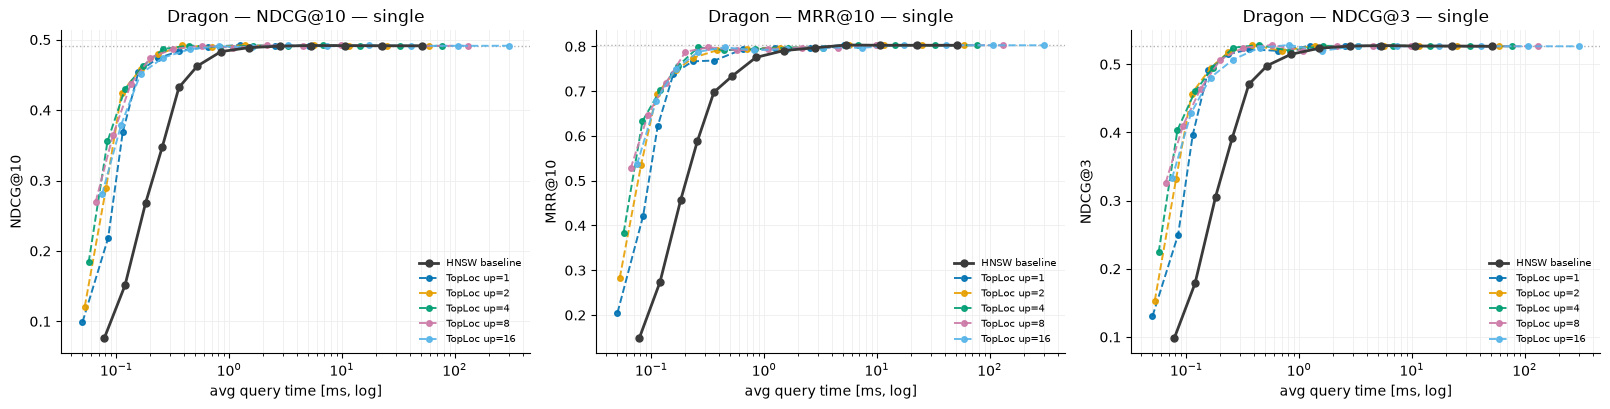

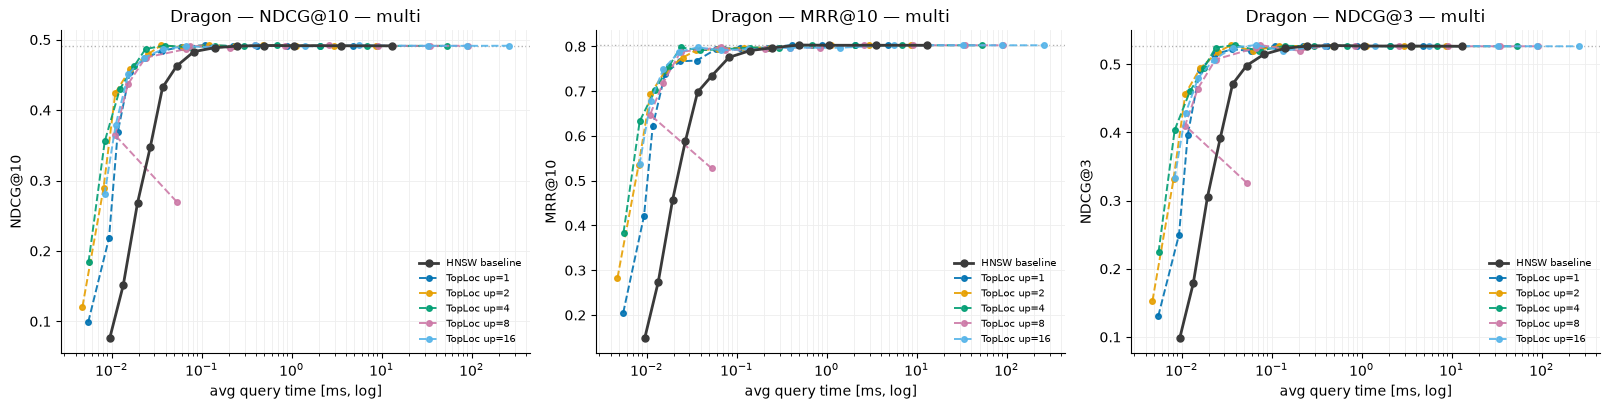

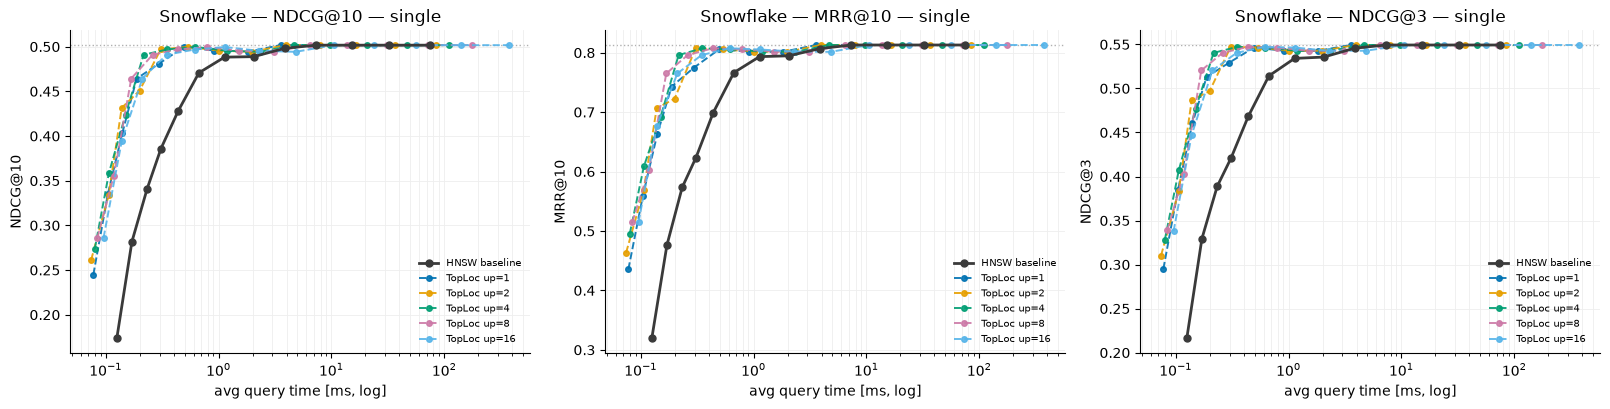

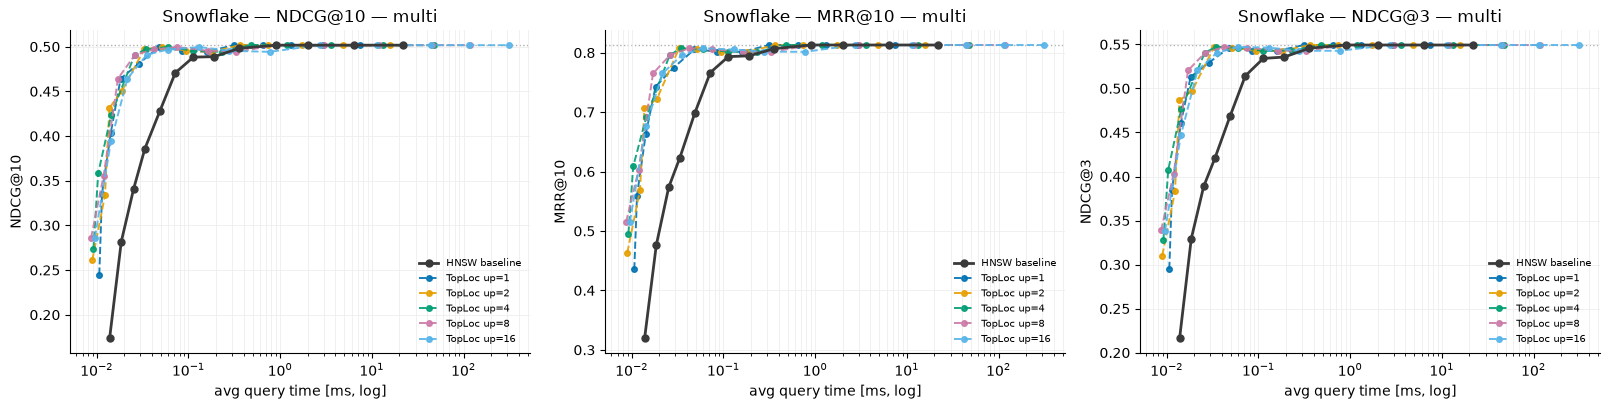

In [6]:
UP_COLORS = {1: "#0072B2", 2: "#E69F00", 4: "#009E73",
             8: "#CC79A7", 16: "#56B4E9"}   # fixed per up (Okabe-Ito)


def plot_metric(model, mode, metric, ax):
    b, t = frames(model, mode)
    b = b.sort_values("efSearch")
    ax.plot(b[TIME], b[metric], "-o", color="#3a3a3a", lw=2, ms=5,
            label="HNSW baseline", zorder=3)
    for up in sorted(t["up"].dropna().unique()):
        g = t[t["up"] == up].sort_values("efSearch")
        ax.plot(g[TIME], g[metric], "--o", lw=1.4, ms=4, alpha=0.9,
                color=UP_COLORS.get(int(up), "#888888"),
                label=f"TopLoc up={int(up)}")
    anchor, _ = stabilized_quality(b, metric)
    ax.axhline(anchor, color="#b0b0b0", lw=1, ls=":", zorder=1)

    ax.set_xscale("log")
    ax.set_xlabel("avg query time [ms, log]")
    ax.set_ylabel(metric)
    ax.set_title(f"{model} — {metric} — {mode}")
    ax.grid(True, which="both", color="#eeeeee", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, frameon=False)


for model in MODELS:
    for mode in MODES:
        fig, axes = plt.subplots(1, len(METRICS),
                                 figsize=(5.4 * len(METRICS), 4.2))
        for ax, metric in zip(np.atleast_1d(axes), METRICS):
            plot_metric(model, mode, metric, ax)
        fig.tight_layout()
        plt.show()

## Paper-style HNSW table

Reproduces the HNSW block of the paper's Table 1 from our runs: one plain-HNSW
row and one TopLoc row per model, with average query time in msec and the
speedup in parentheses. Two rows per model:

* **HNSW** — the cheapest baseline clearing the same quality floor as TopLoc
  (the symmetric, tolerance-matched reference; its time is the denominator of
  the reported speedup).
* **TopLoc HNSW** — the best combined-analysis config at that model's
  tolerance from `REPORT_TOLS` (Dragon: 0.01; Snowflake: 0.0, i.e. zero loss).

In [7]:
def paper_style_table(mode=None, tols=None):
    mode = mode or REPORT_MODE
    tols = tols or REPORT_TOLS
    rows = []
    for model in MODELS:
        tol = tols[model]
        b, t = frames(model, mode)
        tbl, info = quality_loss_table_all(model, mode, tol)
        if tbl.empty:
            print(f"{model}: no qualifying config at TOL={tol}")
            continue
        best = tbl.iloc[0]
        matched_ms = float(best["baseline ms/query"])
        matched_ref = b.loc[(b[TIME] - matched_ms).abs().idxmin()]
        sp = matched_ms / float(best["TopLoc ms/query"])

        rows.append({"Model": model,
                     "Search": f"HNSW (ef={int(matched_ref['efSearch'])})",
                     **{m: float(matched_ref[m])
                        for m in ("MRR@10", "NDCG@3", "NDCG@10")},
                     "Time (ms)": f"{matched_ref[TIME]:.3f}   (-)"})
        rows.append({"Model": model,
                     "Search": f"TopLoc HNSW (up={int(best['up'])}, "
                               f"ef={int(best['ef'])})",
                     "MRR@10": float(best["TopLoc MRR@10"]),
                     "NDCG@3": float(best["TopLoc NDCG@3"]),
                     "NDCG@10": float(best["TopLoc NDCG@10"]),
                     "Time (ms)": f"{best['TopLoc ms/query']:.3f}   ({sp:.1f}x)"})
        print(f"{model}: TOL={tol} -> speedup {sp:.2f}x "
              f"(matched baseline ef={int(matched_ref['efSearch'])}, mode={mode})")
    out = pd.DataFrame(rows).set_index(["Model", "Search"])
    return out.round(4)


print(f"TREC CAsT 2019 - our results [{REPORT_MODE}-thread]")
print("Both rows are tolerance-matched (symmetric comparison); "
      "speedup in parentheses is vs the HNSW row above it.\n")
tbl = paper_style_table()
display(tbl)
tbl.to_csv("paper_style_hnsw_table.csv")

TREC CAsT 2019 - our results [multi-thread]
Both rows are tolerance-matched (symmetric comparison); speedup in parentheses is vs the HNSW row above it.

Dragon: TOL=0.01 -> speedup 10.45x (matched baseline ef=256, mode=multi)
Snowflake: TOL=0.0 -> speedup 2.86x (matched baseline ef=512, mode=multi)


MRR@10  NDCG@3  NDCG@10        Time (ms)
Model     Search                                                              
Dragon    HNSW (ef=256)               0.7969  0.5267   0.4909      0.250   (-)
          TopLoc HNSW (up=4, ef=16)   0.7978  0.5243   0.4868  0.024   (10.5x)
Snowflake HNSW (ef=512)               0.8129  0.5493   0.5017      0.904   (-)
          TopLoc HNSW (up=1, ef=256)  0.8129  0.5493   0.5019   0.316   (2.9x)

## Original: Table 1 from the paper (for comparison)

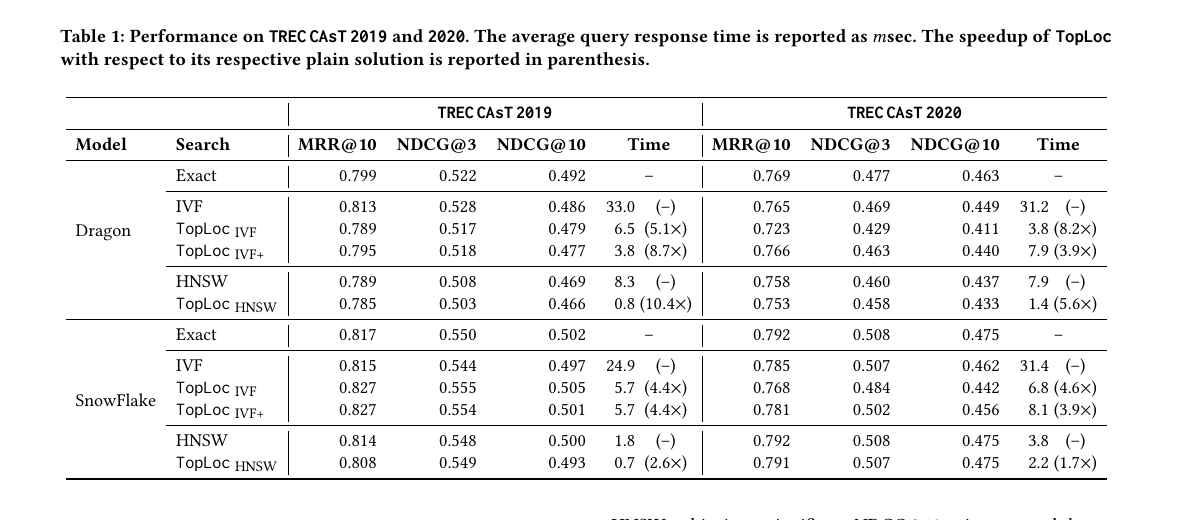

Source: C. I. Muntean, F. M. Nardini, R. Perego, G. Rocchietti, C. Rulli,
*Efficient Conversational Search via Topical Locality in Dense Retrieval*,
SIGIR '25, https://doi.org/10.1145/3726302.3730186 — licensed CC BY 4.0.
Compare our table against the **HNSW / TopLoc-HNSW rows, TREC CAsT 2019
columns**. Note their speedup is reported against their single chosen HNSW
operating point, on different hardware (4-socket Xeon, numactl one socket) and
a grid over m in {16, 32, 64}; ours uses M=32 and a symmetric tolerance-matched
baseline, so times are not directly comparable — the speedup ratios and metric
values are.

## How to read the tables

Each analysis block prints the process (anchor, tolerance, floor, matched
baseline) and then every qualifying TopLoc config sorted by speedup, best
highlighted. `quality loss` is measured against the baseline anchor (negative =
TopLoc exceeds it). The combined tables apply the tolerance to all three metrics
at once. The paper-style table condenses this into the Table-1 format; the
printed line above it also gives the speedup vs the plateau baseline, which is
the paper's (asymmetric) style of reference.